In [1]:
import pandas as pd
import numpy as np

Load the CSV

In [2]:
df_raw = pd.read_csv("../data/Filtered_Sheffield_Traffic_Data.csv",
                     low_memory=False)

df = df_raw.copy()
print(f"Raw rows: {len(df)}")


Raw rows: 7933


Exploratory Data Analysis

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df.describe(include="all"))

#check the distribution of the targt variable "collision_severity"
print(df["collision_severity"].value_counts())


(7933, 44)
collision_index                                         str
collision_year                                        int64
collision_ref_no                                        str
location_easting_osgr                               float64
location_northing_osgr                              float64
longitude                                           float64
latitude                                            float64
police_force                                          int64
collision_severity                                    int64
number_of_vehicles                                    int64
number_of_casualties                                  int64
date                                                    str
day_of_week                                           int64
time                                                    str
local_authority_district                              int64
local_authority_ons_district                            str
local_authority_highway      

Handle Sentinel / Missing Values

STATS19 encodes missing data as -1.

In [4]:
sentinel_cols = ["junction_control", "junction_detail", "pedestrian_crossing_human_control",
                 "pedestrian_crossing_physical_facilities", "special_conditions_at_site",
                 "carriageway_hazards", "did_police_officer_attend_scene_of_accident"]
for col in sentinel_cols:
    if col in df.columns:
        df[col] = df[col].replace(-1, np.nan)

#convert "hh:mm" string to integer hour
df["hour"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.hour


Impute the Missing Values

In [5]:
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

imp_median = SimpleImputer(strategy="median")
df[numeric_cols] = imp_median.fit_transform(df[numeric_cols])

imp_mode = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = imp_mode.fit_transform(df[categorical_cols])


C:\Users\Noel\AppData\Local\Temp\ipykernel_5060\589662157.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


Outlier detection using the IQR and Scaling using RobustScaler as some columns might still be skewed even after clipping

In [6]:
from sklearn.preprocessing import RobustScaler

cols_to_clip = ["number_of_vehicles", "number_of_casualties", "speed_limit"]

for col in cols_to_clip:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Only apply clipping if there is actual variance (IQR > 0)
    # This prevents the column from being squashed into a single constant number
    if IQR > 0:
        df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

rs = RobustScaler()
df[cols_to_clip] = rs.fit_transform(df[cols_to_clip])

Im now going to visualise the before and after the data preprocessing

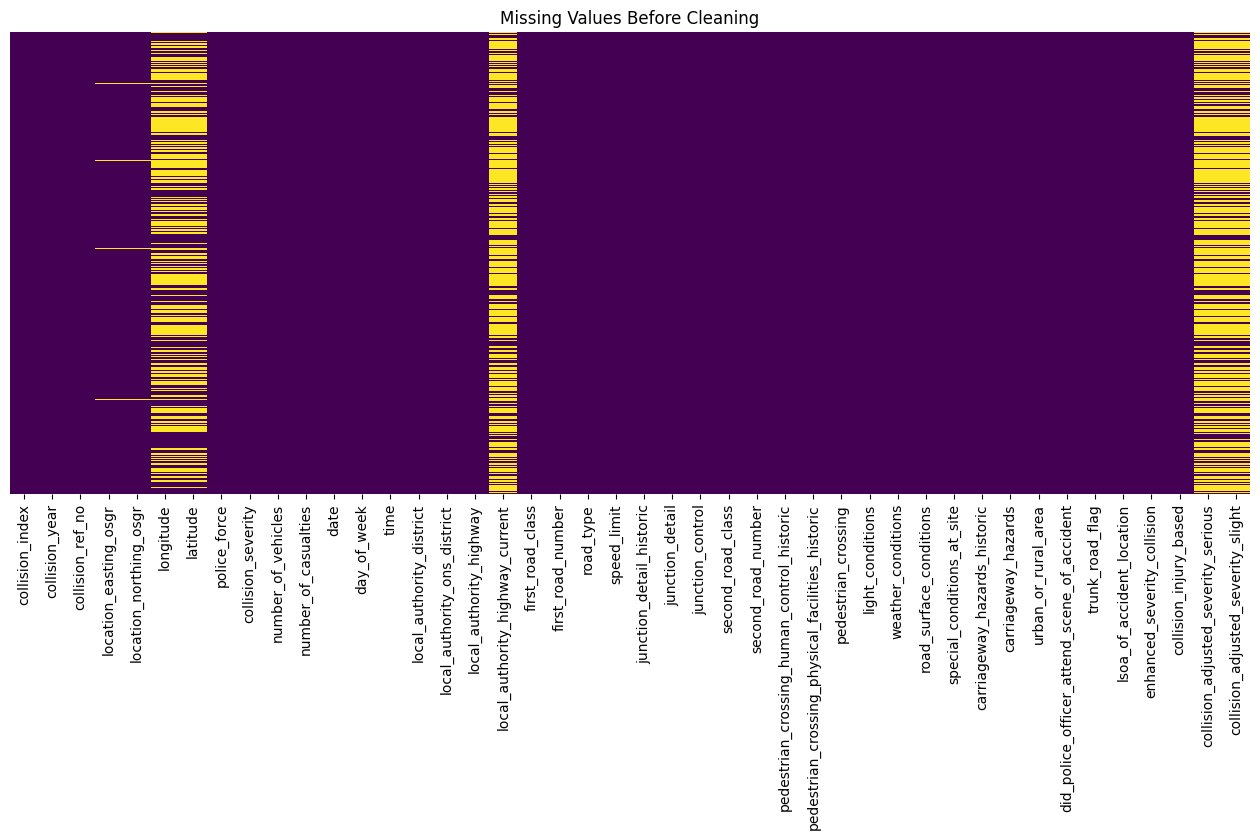

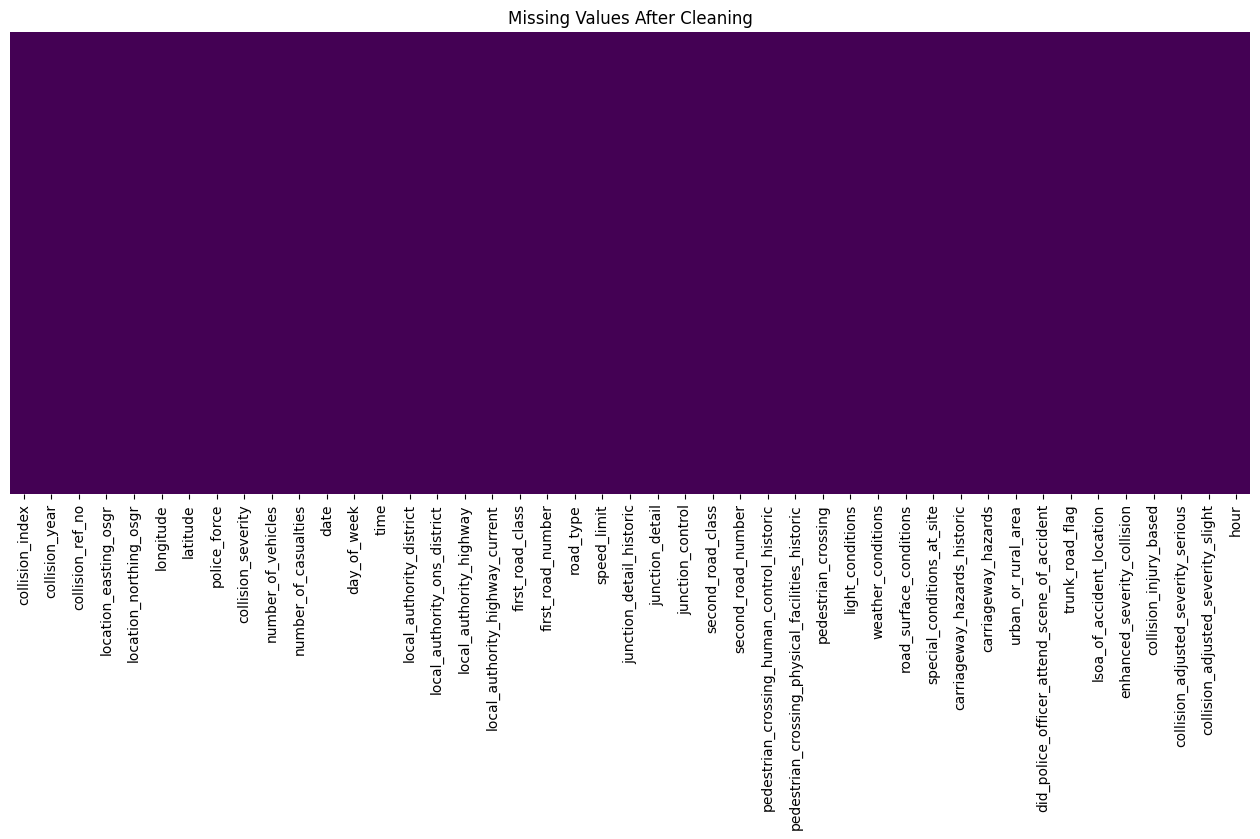

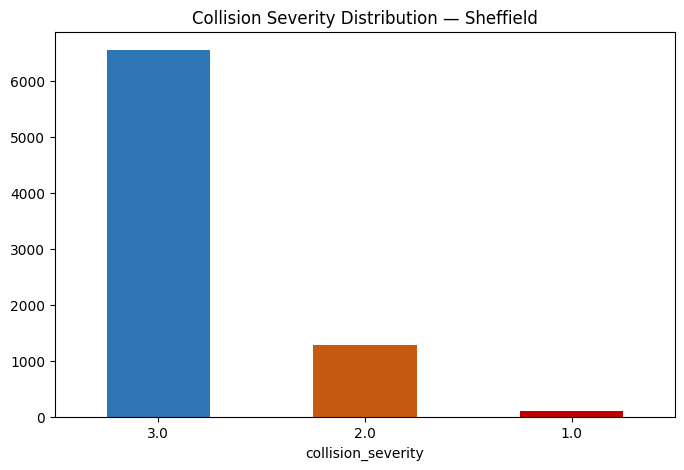

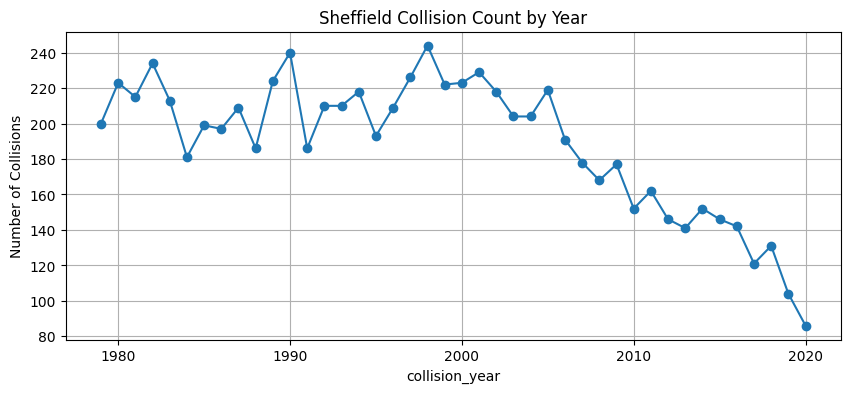

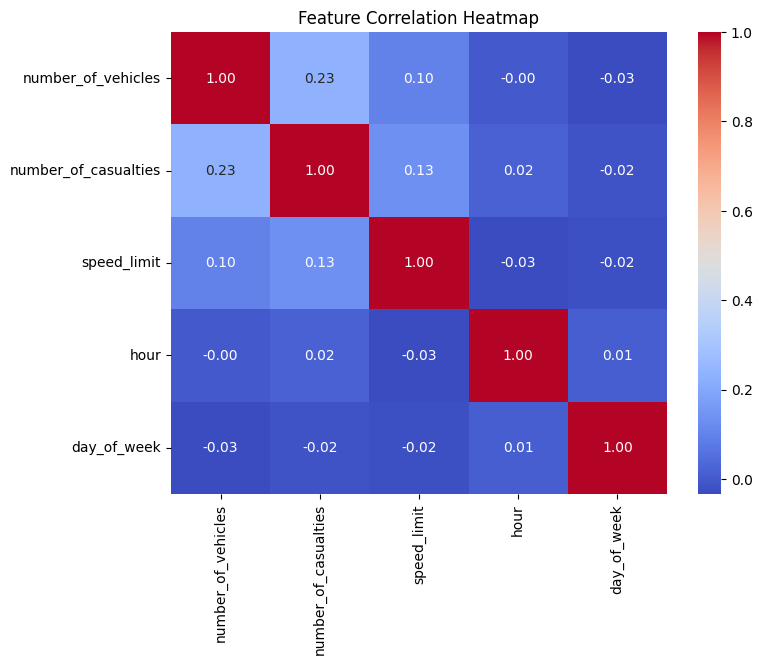

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#missing values heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(df_raw.isnull(),
            yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values Before Cleaning")
plt.savefig("../results/C1-missing_before.png", bbox_inches="tight")

plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(),
            yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values After Cleaning")
plt.savefig("../results/C1-missing_after.png", bbox_inches="tight")

plt.figure(figsize=(8,5))
df["collision_severity"].value_counts().plot(kind="bar", color=["#2E75B6","#C55A11","#C00000"])
plt.title("Collision Severity Distribution — Sheffield")
plt.xticks(rotation=0) 
plt.savefig("../results/C1-severity_dist.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,4))
df.groupby("collision_year").size().plot(marker="o")
plt.title("Sheffield Collision Count by Year")
plt.ylabel("Number of Collisions")
plt.grid(True)#grid to make it easier to read the trend
plt.savefig("../results/C1-trend_year.png", bbox_inches="tight")
plt.show()

feat = ["number_of_vehicles","number_of_casualties","speed_limit","hour","day_of_week"]
plt.figure(figsize=(8,6))
sns.heatmap(df[feat].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("../results/C1-correlation.png", bbox_inches="tight")
plt.show()

# Exploratory Data Analysis — Sheffield Collisions
1. Data Completeness & Cleaning

Before Cleaning: The initial missing values heatmap highlights significant data gaps in latitude and longitude.

After Cleaning: The post-cleaning heatmap demonstrates a completely solid color block, confirming that the imputation strategy (median for numerics, mode for categoricals) successfully resolved all NaN values.

2. Target Variable: Collision Severity

Highly Imbalanced Classes: The bar chart reveals a severe class imbalance in collision severity. Almost all of the collisions are marked as 'Slight', this will have a huge effect when it comes to creating the models later.

I will likely need to apply a class balancing technique like SMOTE, class weighting or undersampling to prevent the model from predicting Slight every time.

3. Temporal Trends (1979–2020)

Historical Fluctuations: From 1979 through the mid-2000s, the annual collision count in Sheffield fluctuated relatively consistently between 180 and 240 incidents per year.

Long-term Decline: Starting around 2008–2010, there is a distinct and steady downward trend in total annual collisions.

2020 Drop: The sharp drop at the very end of the timeline (falling below 90 incidents in 2020) is highly pronounced. This is almost certainly an anomaly caused by reduced traffic volumes during the COVID-19 pandemic lockdowns.

4. Feature Correlation (Numeric Variables)

Overall Weak Linear Relationships: The heatmap indicates very weak linear correlations between most key numeric features. For instance, time-based features like hour and day_of_week show practically zero correlation with crash metrics. This suggests that these variables operate fairly independently of one another during a collision event.

Notable Interactions: The strongest relationship on the board is a weak positive correlation (0.22) between number_of_vehicles and number_of_casualties. This logically aligns with reality: multi-vehicle pileups are slightly more likely to result in multiple injuries. There is also a very minor positive correlation (0.12) between speed_limit and number_of_casualties.

Modeling Takeaway: Because the standard linear correlation between these features is so low, simple linear models (like basic Logistic Regression) might struggle to find meaningful patterns. Moving forward, tree-based models (like Random Forest or XGBoost) will likely be much more effective, as they are capable of capturing complex, non-linear relationships and interactions between these independent features.

In [8]:
#Save the preprocessed data to a new CSV file
df.to_csv("../data/Preprocessed_Traffic_Data.csv", index=False)